# Lambda pair spin-correlation analysis

This notebook is written for the output of `MakeLambdaSpinCorrelationHistograms.C`.

It is intentionally ROOT-first and uses

```python
import ROOT as root
```

throughout.  The notebook handles:

- all single-candidate QA for Lambda, anti-Lambda, K0S, and Phi;
- US-US, US-LS, LS-LS, and optional mixed-event pair outputs;
- all pair channels written by the histogram macro;
- short-range / long-range / inclusive pair selections;
- all crossing categories, especially same-crossing vs different-crossing;
- 2D double-mass signal extraction;
- projections of the 3D mass-mass-cos(theta*) histogram;
- optional mixed-event acceptance correction;
- Eq. (1) slope / Lambda-pair polarization extraction;
- background-only checks;
- K0S and Phi control correlations;
- a compact summary ROOT file and multipage QA PDFs.

The physics extraction section follows the STAR strategy qualitatively: US-US and US-LS double-mass distributions are compared/subtracted, the signal region is taken from a 2D Gaussian fit, and the final angular distribution can be mixed-event corrected before fitting.

In [1]:
import ROOT as root
import os
import math
import csv

root.gROOT.SetBatch(True)
root.gStyle.SetOptStat(0)
root.gStyle.SetOptFit(1111)
root.gStyle.SetTitleBorderSize(0)
root.gStyle.SetPadTickX(1)
root.gStyle.SetPadTickY(1)

# Keep ROOT objects alive in PyROOT.
plot_keepalive = []

Welcome to JupyROOT 6.30/06


## Input and analysis configuration

In [2]:
# ------------------------------------------------------------------
# Main input/output settings
# ------------------------------------------------------------------

input_file = "input/pp_Lambda_spin_79513_prod_histonly_v1.root"
plot_dir = "output/lambda_spin_plots"
os.makedirs(plot_dir, exist_ok=True)

# Main samples to inspect.
pair_sources = ["USUS", "USLS", "LSLS"]
pair_types = [
    "LambdaLambda",
    "LambdaAntiLambda",
    "AntiLambdaAntiLambda",
    "K0SK0S",
    "K0SLambda",
    "K0SAntiLambda",
    "LambdaPhi",
    "AntiLambdaPhi",
    "K0SPhi",
]
pair_ranges = ["all", "short", "long"]

crossing_classes = [
    "all",
    "bothCandidatesDaughtersSame",
    "sameCrossing",
    "differentCrossing",
    "internalMismatch",
    "invalidCrossing",
]

candidate_species = ["Lambda", "AntiLambda", "K0S", "Phi"]
candidate_signs = ["US", "LS"]

# ------------------------------------------------------------------
# Plot / processing switches
# ------------------------------------------------------------------

MAKE_CANDIDATE_QA = True
MAKE_PAIR_QA = True
MAKE_CROSSING_QA = True
MAKE_SIGNAL_EXTRACTION = True
MAKE_SPIN_SUMMARY = True

# The exhaustive book can be large.  Turn this on only when desired.
MAKE_FULL_PAIR_BOOK = False

# Rebinning used only for presentation / fits; original file is untouched.
COS_REBIN = 1
MASS_REBIN = 1

# For log-z mass/crossing plots.
USE_LOGZ = True

# ------------------------------------------------------------------
# Signal extraction configuration
# ------------------------------------------------------------------

# "fit" = obtain mean/sigma from USUS - scale*USLS 2D mass plane.
# "fixed" = use fixed_windows below directly.
signal_window_mode = "constrained_fit"

# Number of fitted sigma in EACH mass direction.
signal_nsigma = 2.0

# These are fallback / manual windows, not hard-coded physics truth.
# Tune them after looking at the data if signal_window_mode = "fixed".
fixed_windows = {
    "Lambda":     (1.108, 1.123),
    "AntiLambda": (1.108, 1.123),
    "K0S":        (0.485, 0.510),
    "Phi":        (1.005, 1.035),
}

# Constrained 2D Gaussian fit: keep the means near the known peaks and widths
# inside a sensible detector-resolution range. Failed/boundary fits fall back
# to the fixed windows above.
fit_mean_limits = {
    "Lambda":     (1.108, 1.123),
    "AntiLambda": (1.108, 1.123),
    "K0S":        (0.485, 0.510),
    "Phi":        (1.005, 1.035),
}

fit_sigma_limits = {
    "Lambda":     (0.0010, 0.0120),
    "AntiLambda": (0.0010, 0.0120),
    "K0S":        (0.0020, 0.0250),
    "Phi":        (0.0010, 0.0200),
}

# Very robust low-statistics cross-check. No US-LS normalization and no 2D
# Gaussian are required: use a fixed central double-mass box and estimate the
# local background from the surrounding rectangular ring.
MAKE_SIMPLE_SIDEBAND_ANALYSIS = True
simple_sideband_outer_scale = 2.0
min_entries_for_angular_fit = 8.0

# Background normalization for the US-LS 2D plane:
#   "sideband" -> normalize USLS to USUS in the outer mass-plane region
#   "unity"    -> direct USUS - USLS subtraction
background_normalization = "sideband"

# Fraction of each mass axis kept as the central signal-like box when
# defining the OUTER sideband region.  0.35 means central 35% on each axis.
central_box_fraction_for_sideband = 0.35

# Eq. (1) decay parameters.
alpha_lambda = +0.747
alpha_antilambda = -0.757

# Restrict fit range if desired.
cos_fit_min = -1.0
cos_fit_max = +1.0

## Open the ROOT file and inspect metadata

In [3]:
f = root.TFile.Open(input_file, "READ")

if not f or f.IsZombie():
    raise RuntimeError(f"Could not open {input_file}")

print("Opened:", input_file)

def print_named(name):
    obj = f.Get(name)
    if obj:
        if hasattr(obj, "GetTitle"):
            print(f"{name}: {obj.GetTitle()}")
        elif hasattr(obj, "GetVal"):
            print(f"{name}: {obj.GetVal()}")

for name in [
    "analysis_method",
    "identity_branches",
    "crossing_definition",
    "event_definition",
    "pair_range_definition",
    "mixed_event_definition",
    "control_angle_definition",
]:
    print_named(name)

for name in ["mixed_event_enabled", "alpha_Lambda", "alpha_AntiLambda",
             "processed_entries", "processed_event_groups"]:
    print_named(name)

mixed_event_enabled = False
mixed_flag = f.Get("mixed_event_enabled")
if mixed_flag:
    mixed_event_enabled = bool(mixed_flag.GetVal())

print("Mixed event available:", mixed_event_enabled)

Opened: input/pp_Lambda_spin_79513_prod_histonly_v1.root
analysis_method: Same-event Lambda/Lambda-bar/K0S/Phi correlation histogram producer; Lambda spin observable follows arXiv:2506.05499; K0S/Phi combinations are control correlations; V0s use secondary-PCA momenta and Phi uses stored primary-PCA momenta.
identity_branches: evt=evt, run=run, daughter tracks=track_id1/track_id2
crossing_definition: A candidate has an internally resolved crossing only when crossing_valid1==1 AND crossing_valid2==1 AND crossing1==crossing2. Crossing value 0 is allowed when valid. sameCrossing/differentCrossing pair folders are filled only after both candidates satisfy this internal requirement.
event_definition: Candidates are grouped by input-file, run and evt. evt is the input frame/event sequence; multiple physical crossings inside the same evt are intentionally retained and separated by crossing QA.
pair_range_definition: short: |Delta y|<0.5 AND |Delta phi|<pi/3; long: (0.5<=|Delta y|<2) OR (pi/3<

In [4]:
# Optional: recursively print the file structure.

def print_root_directory(directory, prefix=""):
    keys = directory.GetListOfKeys()
    for key in keys:
        obj = key.ReadObj()
        print(prefix + obj.GetName(), obj.ClassName())
        if obj.InheritsFrom("TDirectory"):
            print_root_directory(obj, prefix + "  ")

# Uncomment if useful:
# print_root_directory(f)

## General ROOT helpers

In [5]:
def get_obj(path, required=True):
    obj = f.Get(path)
    if not obj and required:
        raise KeyError(f"Missing ROOT object: {path}")
    return obj


def clone_detached(hist, name=None):
    if hist is None:
        return None
    clone_name = name if name is not None else hist.GetName() + "_clone"
    h = hist.Clone(clone_name)
    if h.InheritsFrom("TH1"):
        h.SetDirectory(0)
        h.Sumw2()
    plot_keepalive.append(h)
    return h


def get_hist(path, required=True, clone=True):
    h = get_obj(path, required=required)
    if not h:
        return None
    if clone:
        return clone_detached(h, h.GetName() + "_work")
    return h


def normalize_hist(h, width=False):
    if not h:
        return None
    option = "width" if width else ""
    integral = h.Integral(option)
    if integral > 0:
        h.Scale(1.0 / integral)
    return h


def set_line(h, color, marker=20, width=2):
    h.SetLineColor(color)
    h.SetMarkerColor(color)
    h.SetMarkerStyle(marker)
    h.SetLineWidth(width)


def draw_label(text, x=0.16, y=0.86, size=0.038):
    latex = root.TLatex()
    latex.SetNDC()
    latex.SetTextSize(size)
    latex.DrawLatex(x, y, text)
    plot_keepalive.append(latex)
    return latex


def draw_legend(items, x1=0.58, y1=0.68, x2=0.88, y2=0.88):
    leg = root.TLegend(x1, y1, x2, y2)
    leg.SetBorderSize(0)
    leg.SetFillStyle(0)
    for obj, label, option in items:
        leg.AddEntry(obj, label, option)
    leg.Draw()
    plot_keepalive.append(leg)
    return leg


def pdf_open(canvas, filename):
    canvas.Print(filename + "[")


def pdf_close(canvas, filename):
    canvas.Print(filename + "]")


def pair_path(source, pair_type, range_name, crossing_class, hist_name):
    return (
        f"pairs/{source}/{pair_type}/{range_name}/"
        f"{crossing_class}/{hist_name}"
    )


def candidate_path(sign, species, hist_name):
    return f"candidates/{sign}/{species}/{hist_name}"


pair_type_species = {
    "LambdaLambda": ("Lambda", "Lambda"),
    "LambdaAntiLambda": ("Lambda", "AntiLambda"),
    "AntiLambdaAntiLambda": ("AntiLambda", "AntiLambda"),
    "K0SK0S": ("K0S", "K0S"),
    "K0SLambda": ("K0S", "Lambda"),
    "K0SAntiLambda": ("K0S", "AntiLambda"),
    "LambdaPhi": ("Lambda", "Phi"),
    "AntiLambdaPhi": ("AntiLambda", "Phi"),
    "K0SPhi": ("K0S", "Phi"),
}


def object_exists(path):
    return bool(f.Get(path))

## Event-level and global QA

pairSummary tree not present


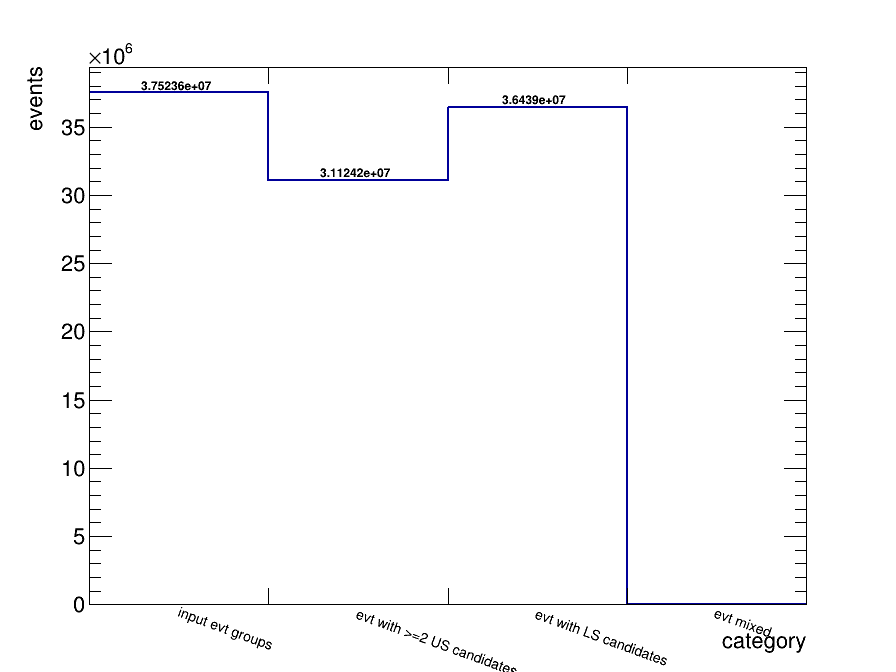

In [6]:
h_event_counts = get_hist("h_event_counts", required=False)

if h_event_counts:
    c_event = root.TCanvas("c_event_counts", "event counts", 900, 700)
    h_event_counts.SetLineWidth(2)
    h_event_counts.Draw("hist text0")
    c_event.Update()
    plot_keepalive.extend([c_event, h_event_counts])

summary_tree = f.Get("pairSummary")
if summary_tree:
    print("pairSummary entries:", summary_tree.GetEntries())
else:
    print("pairSummary tree not present")

## Candidate QA

In [7]:
def make_candidate_qa_pdf(
    filename=os.path.join(plot_dir, "candidate_qa.pdf"),
    include_ls=True,
):
    canvas = root.TCanvas("c_candidate_qa", "candidate QA", 1500, 1100)
    pdf_open(canvas, filename)

    signs = ["US", "LS"] if include_ls else ["US"]

    for sign in signs:
        for species in candidate_species:
            mass_path = candidate_path(sign, species, "h_mass")
            if not object_exists(mass_path):
                continue

            canvas.Clear()
            canvas.Divide(2, 2)

            # ------------------------------------------------------
            # Pad 1: invariant mass
            # ------------------------------------------------------
            canvas.cd(1)
            h_mass = get_hist(mass_path)
            if MASS_REBIN > 1:
                h_mass.Rebin(MASS_REBIN)
            h_mass.SetLineWidth(2)
            h_mass.Draw("hist e")
            draw_label(f"{sign} {species}", 0.17, 0.86)

            # ------------------------------------------------------
            # Pad 2: mass vs pT
            # ------------------------------------------------------
            canvas.cd(2)
            h_mpt = get_hist(
                candidate_path(sign, species, "h_mass_vs_pt"),
                required=False,
            )
            if h_mpt:
                if USE_LOGZ:
                    root.gPad.SetLogz()
                h_mpt.Draw("colz")

            # ------------------------------------------------------
            # Pad 3: crossing1 vs crossing2
            # ------------------------------------------------------
            canvas.cd(3)
            h_cross = get_hist(
                candidate_path(sign, species, "h_crossing1_vs_crossing2"),
                required=False,
            )
            if h_cross:
                if USE_LOGZ:
                    root.gPad.SetLogz()
                h_cross.Draw("colz")

            # ------------------------------------------------------
            # Pad 4: crossing status
            # ------------------------------------------------------
            canvas.cd(4)
            h_status = get_hist(
                candidate_path(sign, species, "h_crossing_status"),
                required=False,
            )
            if h_status:
                h_status.Draw("hist text0")

            canvas.Print(filename)

            # ------------------------------------------------------
            # Second page: topology/PID QA
            # ------------------------------------------------------
            canvas.Clear()
            canvas.Divide(2, 2)

            plots = [
                ("h_mass_vs_pairDCA", "colz"),
                ("h_mass_vs_decayR", "colz"),
                ("h_mass_vs_DIRA", "colz"),
                ("h_analyzer_dedx_vs_p", "colz"),
            ]

            for ipad, (hist_name, draw_opt) in enumerate(plots, start=1):
                canvas.cd(ipad)
                h = get_hist(
                    candidate_path(sign, species, hist_name),
                    required=False,
                )
                if h:
                    if draw_opt == "colz" and USE_LOGZ:
                        root.gPad.SetLogz()
                    h.Draw(draw_opt)

            canvas.Print(filename)

    pdf_close(canvas, filename)
    print("Wrote", filename)


if MAKE_CANDIDATE_QA:
    make_candidate_qa_pdf()

Wrote output/lambda_spin_plots/candidate_qa.pdf


Info in <TCanvas::Print>: pdf file output/lambda_spin_plots/candidate_qa.pdf has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_qa.p

## Candidate crossing comparison

In [8]:
def make_candidate_crossing_summary(
    filename=os.path.join(plot_dir, "candidate_crossing_summary.pdf"),
):
    canvas = root.TCanvas(
        "c_candidate_crossing_summary",
        "candidate crossing summary",
        1500,
        1100,
    )
    pdf_open(canvas, filename)

    for sign in candidate_signs:
        for species in candidate_species:
            base = candidate_path(sign, species, "h_mass")
            if not object_exists(base):
                continue

            canvas.Clear()
            canvas.Divide(2, 2)

            canvas.cd(1)
            h1 = get_hist(candidate_path(sign, species, "h_crossing_validity"))
            h1.Draw("hist text0")

            canvas.cd(2)
            h2 = get_hist(candidate_path(sign, species, "h_crossing_status"))
            h2.Draw("hist text0")

            canvas.cd(3)
            h3 = get_hist(candidate_path(sign, species, "h_mass_vs_delta_crossing"))
            root.gPad.SetLogz(USE_LOGZ)
            h3.Draw("colz")

            canvas.cd(4)
            h4 = get_hist(candidate_path(sign, species, "h_analyzer_pt_vs_parent_pt"))
            root.gPad.SetLogz(USE_LOGZ)
            h4.Draw("colz")

            draw_label(f"{sign} {species}", 0.17, 0.92)
            canvas.Print(filename)

    pdf_close(canvas, filename)
    print("Wrote", filename)


if MAKE_CROSSING_QA:
    make_candidate_crossing_summary()

Wrote output/lambda_spin_plots/candidate_crossing_summary.pdf


Info in <TCanvas::Print>: pdf file output/lambda_spin_plots/candidate_crossing_summary.pdf has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_crossing_summary.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_crossing_summary.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_crossing_summary.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_crossing_summary.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_crossing_summary.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_crossing_summary.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/candidate_crossing_summary.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/can

## Pair QA helper

In [9]:
def make_pair_qa_pages(
    canvas,
    pdf_filename,
    source,
    pair_type,
    range_name="all",
    crossing_class="all",
):
    base = f"pairs/{source}/{pair_type}/{range_name}/{crossing_class}"

    if not object_exists(base + "/h_cosThetaStar"):
        return

    # ==============================================================
    # Page 1: double mass and cos(theta*)
    # ==============================================================
    canvas.Clear()
    canvas.Divide(2, 2)

    canvas.cd(1)
    h_massmass = get_hist(base + "/h_mass1_vs_mass2")
    if USE_LOGZ:
        root.gPad.SetLogz()
    h_massmass.Draw("colz")

    canvas.cd(2)
    h_cos = get_hist(base + "/h_cosThetaStar")
    if COS_REBIN > 1:
        h_cos.Rebin(COS_REBIN)
    h_cos.SetLineWidth(2)
    h_cos.Draw("hist e")

    canvas.cd(3)
    h_m1 = get_hist(base + "/h_mass1")
    h_m1.SetLineWidth(2)
    h_m1.Draw("hist e")

    canvas.cd(4)
    h_m2 = get_hist(base + "/h_mass2")
    h_m2.SetLineWidth(2)
    h_m2.Draw("hist e")

    draw_label(
        f"{source}, {pair_type}, {range_name}, {crossing_class}",
        0.13,
        0.94,
        0.032,
    )
    canvas.Print(pdf_filename)

    # ==============================================================
    # Page 2: pair relative kinematics
    # ==============================================================
    canvas.Clear()
    canvas.Divide(2, 2)

    pair_qa = [
        ("h_absDeltaY", "hist e"),
        ("h_absDeltaPhi", "hist e"),
        ("h_deltaR", "hist e"),
        ("h_absDeltaY_vs_absDeltaPhi", "colz"),
    ]

    for ipad, (hist_name, draw_opt) in enumerate(pair_qa, start=1):
        canvas.cd(ipad)
        h = get_hist(base + "/" + hist_name, required=False)
        if h:
            if draw_opt == "colz" and USE_LOGZ:
                root.gPad.SetLogz()
            h.Draw(draw_opt)

    draw_label(
        f"{source}, {pair_type}, {range_name}, {crossing_class}",
        0.13,
        0.94,
        0.032,
    )
    canvas.Print(pdf_filename)

    # ==============================================================
    # Page 3: candidate/analyzer correlations
    # ==============================================================
    canvas.Clear()
    canvas.Divide(2, 2)

    pair_qa = [
        "h_pt1_vs_pt2",
        "h_y1_vs_y2",
        "h_analyzer_pt1_vs_pt2",
        "h_analyzer_pstar1_vs_pstar2",
    ]

    for ipad, hist_name in enumerate(pair_qa, start=1):
        canvas.cd(ipad)
        h = get_hist(base + "/" + hist_name, required=False)
        if h:
            if USE_LOGZ:
                root.gPad.SetLogz()
            h.Draw("colz")

    draw_label(
        f"{source}, {pair_type}, {range_name}, {crossing_class}",
        0.13,
        0.94,
        0.032,
    )
    canvas.Print(pdf_filename)

    # ==============================================================
    # Page 4: angular dependence
    # ==============================================================
    canvas.Clear()
    canvas.Divide(2, 2)

    pair_qa = [
        "h_cosThetaStar_vs_deltaR",
        "h_cosThetaStar_vs_absDeltaY",
        "h_cosThetaStar_vs_absDeltaPhi",
        "h_cosThetaStar_vs_avg_pair_pt",
    ]

    for ipad, hist_name in enumerate(pair_qa, start=1):
        canvas.cd(ipad)
        h = get_hist(base + "/" + hist_name, required=False)
        if h:
            h.Draw("colz")

    draw_label(
        f"{source}, {pair_type}, {range_name}, {crossing_class}",
        0.13,
        0.94,
        0.032,
    )
    canvas.Print(pdf_filename)

    # ==============================================================
    # Page 5: crossing QA
    # ==============================================================
    canvas.Clear()
    canvas.Divide(2, 2)

    canvas.cd(1)
    h_cat = get_hist(base + "/h_crossing_category", required=False)
    if h_cat:
        h_cat.Draw("hist text0")

    canvas.cd(2)
    h_resolved = get_hist(
        base + "/h_resolved_crossing1_vs_crossing2",
        required=False,
    )
    if h_resolved:
        if USE_LOGZ:
            root.gPad.SetLogz()
        h_resolved.Draw("colz")

    canvas.cd(3)
    h_dedx = get_hist(
        base + "/h_analyzer_dedx1_vs_dedx2",
        required=False,
    )
    if h_dedx:
        if USE_LOGZ:
            root.gPad.SetLogz()
        h_dedx.Draw("colz")

    canvas.cd(4)
    h_p = get_hist(
        base + "/h_analyzer_p1_vs_p2",
        required=False,
    )
    if h_p:
        if USE_LOGZ:
            root.gPad.SetLogz()
        h_p.Draw("colz")

    draw_label(
        f"{source}, {pair_type}, {range_name}, {crossing_class}",
        0.13,
        0.94,
        0.032,
    )
    canvas.Print(pdf_filename)

In [10]:
def make_pair_qa_pdf(
    filename=os.path.join(plot_dir, "pair_qa.pdf"),
    sources=None,
    types=None,
    ranges=None,
    crossings=None,
):
    if sources is None:
        sources = ["USUS"]
    if types is None:
        types = pair_types
    if ranges is None:
        ranges = pair_ranges
    if crossings is None:
        crossings = ["all", "sameCrossing", "differentCrossing"]

    canvas = root.TCanvas("c_pair_qa", "pair QA", 1500, 1100)
    pdf_open(canvas, filename)

    for source in sources:
        for pair_type in types:
            for range_name in ranges:
                for crossing_class in crossings:
                    make_pair_qa_pages(
                        canvas,
                        filename,
                        source,
                        pair_type,
                        range_name,
                        crossing_class,
                    )

    pdf_close(canvas, filename)
    print("Wrote", filename)


if MAKE_PAIR_QA:
    make_pair_qa_pdf(
        sources=["USUS"],
        types=pair_types,
        ranges=["all", "short", "long"],
        crossings=["all", "sameCrossing", "differentCrossing"],
    )

# Truly exhaustive output book, including USLS and LSLS.
if MAKE_FULL_PAIR_BOOK:
    full_sources = list(pair_sources)
    if mixed_event_enabled:
        full_sources.append("MixedEvent")

    make_pair_qa_pdf(
        filename=os.path.join(plot_dir, "pair_qa_FULL.pdf"),
        sources=full_sources,
        types=pair_types,
        ranges=pair_ranges,
        crossings=crossing_classes,
    )

Wrote output/lambda_spin_plots/pair_qa.pdf


Info in <TCanvas::Print>: pdf file output/lambda_spin_plots/pair_qa.pdf has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/pair_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/pair_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/pair_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/pair_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/pair_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/pair_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/pair_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/pair_qa.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/pair_qa.pdf
Info in <TCanvas::Print>: Current canvas added 

## Direct same-crossing vs different-crossing comparison

In [11]:
def compare_crossing_classes(
    pair_type,
    range_name,
    hist_name="h_cosThetaStar",
    source="USUS",
    normalize=True,
):
    same = get_hist(
        pair_path(source, pair_type, range_name, "sameCrossing", hist_name),
        required=False,
    )
    diff = get_hist(
        pair_path(source, pair_type, range_name, "differentCrossing", hist_name),
        required=False,
    )

    if not same or not diff:
        return None, None

    if normalize:
        normalize_hist(same)
        normalize_hist(diff)

    set_line(same, root.kBlue + 1, 20)
    set_line(diff, root.kRed + 1, 24)

    return same, diff


def make_crossing_comparison_pdf(
    filename=os.path.join(plot_dir, "same_vs_different_crossing.pdf"),
):
    canvas = root.TCanvas(
        "c_crossing_compare",
        "same vs different crossing",
        1400,
        1000,
    )
    pdf_open(canvas, filename)

    for pair_type in pair_types:
        for range_name in ["all", "short", "long"]:
            canvas.Clear()
            canvas.Divide(2, 2)

            comparison_hists = [
                "h_cosThetaStar",
                "h_deltaR",
                "h_absDeltaY",
                "h_absDeltaPhi",
            ]

            any_drawn = False

            for ipad, hist_name in enumerate(comparison_hists, start=1):
                canvas.cd(ipad)
                same, diff = compare_crossing_classes(
                    pair_type,
                    range_name,
                    hist_name=hist_name,
                )
                if not same or not diff:
                    continue

                any_drawn = True

                ymax = max(same.GetMaximum(), diff.GetMaximum())
                same.SetMaximum(1.25 * ymax if ymax > 0 else 1.0)
                same.Draw("hist e")
                diff.Draw("hist e same")

                draw_legend([
                    (same, "same resolved crossing", "lep"),
                    (diff, "different resolved crossing", "lep"),
                ])

            if any_drawn:
                draw_label(
                    f"{pair_type}, {range_name}",
                    0.14,
                    0.94,
                    0.035,
                )
                canvas.Print(filename)

    pdf_close(canvas, filename)
    print("Wrote", filename)


if MAKE_CROSSING_QA:
    make_crossing_comparison_pdf()

Wrote output/lambda_spin_plots/same_vs_different_crossing.pdf


Info in <TCanvas::Print>: pdf file output/lambda_spin_plots/same_vs_different_crossing.pdf has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/same_vs_different_crossing.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/same_vs_different_crossing.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/same_vs_different_crossing.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/same_vs_different_crossing.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/same_vs_different_crossing.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/same_vs_different_crossing.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/same_vs_different_crossing.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/sam

## Double-mass signal extraction

The raw pair output contains `h_mass1_vs_mass2` and
`h3_mass1_mass2_cosThetaStar`.

For a given pair type / range / crossing class this section:

1. loads US-US and US-LS mass planes;
2. optionally normalizes US-LS to US-US in a 2D outer sideband;
3. subtracts the background plane;
4. fits the positive signal structure with a factorized 2D Gaussian;
5. defines a per-axis `mean ± N sigma` signal box;
6. uses exactly that box to project cos(theta*) from the TH3.

The sideband scaling is a practical configurable choice for this dataset.  Set
`background_normalization = "unity"` to inspect direct US-US − US-LS subtraction.

In [12]:
def central_box_bins_2d(h2, fraction=0.35):
    nx = h2.GetNbinsX()
    ny = h2.GetNbinsY()

    width_x = max(1, int(round(nx * fraction)))
    width_y = max(1, int(round(ny * fraction)))

    x1 = max(1, (nx - width_x) // 2 + 1)
    x2 = min(nx, x1 + width_x - 1)

    y1 = max(1, (ny - width_y) // 2 + 1)
    y2 = min(ny, y1 + width_y - 1)

    return x1, x2, y1, y2


def integral_outer_sideband(h2, fraction=0.35):
    x1, x2, y1, y2 = central_box_bins_2d(h2, fraction)

    total = h2.Integral(1, h2.GetNbinsX(), 1, h2.GetNbinsY())
    central = h2.Integral(x1, x2, y1, y2)

    return total - central


def usls_scale_from_sideband(h_usus, h_usls):
    usus_sb = integral_outer_sideband(
        h_usus,
        central_box_fraction_for_sideband,
    )
    usls_sb = integral_outer_sideband(
        h_usls,
        central_box_fraction_for_sideband,
    )

    if usls_sb <= 0:
        return 1.0

    return usus_sb / usls_sb


def make_subtracted_mass_plane(
    pair_type,
    range_name,
    crossing_class="all",
):
    h_usus = get_hist(
        pair_path(
            "USUS",
            pair_type,
            range_name,
            crossing_class,
            "h_mass1_vs_mass2",
        )
    )

    h_usls = get_hist(
        pair_path(
            "USLS",
            pair_type,
            range_name,
            crossing_class,
            "h_mass1_vs_mass2",
        ),
        required=False,
    )

    if not h_usls:
        return h_usus, None, clone_detached(
            h_usus,
            f"h_signal_massplane_{pair_type}_{range_name}_{crossing_class}",
        ), 0.0

    if background_normalization == "sideband":
        scale = usls_scale_from_sideband(h_usus, h_usls)
    else:
        scale = 1.0

    h_signal = clone_detached(
        h_usus,
        f"h_signal_massplane_{pair_type}_{range_name}_{crossing_class}",
    )
    h_signal.Add(h_usls, -scale)

    return h_usus, h_usls, h_signal, scale

In [13]:
def fit_2d_gaussian(h2, pair_type, draw=False):
    species1, species2 = pair_type_species[pair_type]

    if signal_window_mode == "fixed":
        w1 = fixed_windows[species1]
        w2 = fixed_windows[species2]
        return {
            "ok": True,
            "used_fallback": False,
            "mu1": 0.5 * (w1[0] + w1[1]),
            "sigma1": 0.5 * (w1[1] - w1[0]) / signal_nsigma,
            "mu2": 0.5 * (w2[0] + w2[1]),
            "sigma2": 0.5 * (w2[1] - w2[0]) / signal_nsigma,
            "window1": w1,
            "window2": w2,
            "fit": None,
            "status": 0,
        }

    mean1 = fit_mean_limits[species1]
    mean2 = fit_mean_limits[species2]
    sig1 = fit_sigma_limits[species1]
    sig2 = fit_sigma_limits[species2]

    mu1_seed = 0.5 * (mean1[0] + mean1[1])
    mu2_seed = 0.5 * (mean2[0] + mean2[1])
    sigma1_seed = min(max(0.25 * (mean1[1] - mean1[0]), sig1[0]), sig1[1])
    sigma2_seed = min(max(0.25 * (mean2[1] - mean2[0]), sig2[0]), sig2[1])

    x_lo = max(h2.GetXaxis().GetXmin(), mu1_seed - 3.0 * sig1[1])
    x_hi = min(h2.GetXaxis().GetXmax(), mu1_seed + 3.0 * sig1[1])
    y_lo = max(h2.GetYaxis().GetXmin(), mu2_seed - 3.0 * sig2[1])
    y_hi = min(h2.GetYaxis().GetXmax(), mu2_seed + 3.0 * sig2[1])

    fit = root.TF2(
        f"f2_gaus_{pair_type}_{abs(hash(h2.GetName()))}",
        "[0]*exp(-0.5*((x-[1])/[2])^2 - 0.5*((y-[3])/[4])^2)",
        x_lo, x_hi, y_lo, y_hi,
    )

    amp_seed = max(h2.GetMaximum(), 1.0)
    fit.SetParameters(amp_seed, mu1_seed, sigma1_seed, mu2_seed, sigma2_seed)

    # Positive signal amplitude; constrained means and widths.
    fit.SetParLimits(0, 0.0, max(1.0e6, 100.0 * amp_seed))
    fit.SetParLimits(1, mean1[0], mean1[1])
    fit.SetParLimits(2, sig1[0], sig1[1])
    fit.SetParLimits(3, mean2[0], mean2[1])
    fit.SetParLimits(4, sig2[0], sig2[1])

    result = h2.Fit(fit, "QRS0")
    status = int(result)

    mu1 = fit.GetParameter(1)
    sigma1 = abs(fit.GetParameter(2))
    mu2 = fit.GetParameter(3)
    sigma2 = abs(fit.GetParameter(4))

    def near_limit(value, limits, frac=0.02):
        lo, hi = limits
        return abs(value-lo) < frac*(hi-lo) or abs(value-hi) < frac*(hi-lo)

    bad = (
        status != 0
        or fit.GetParameter(0) <= 0
        or not all(math.isfinite(v) for v in [mu1, sigma1, mu2, sigma2])
        or near_limit(mu1, mean1)
        or near_limit(mu2, mean2)
        or near_limit(sigma1, sig1)
        or near_limit(sigma2, sig2)
    )

    plot_keepalive.append(fit)

    if bad:
        w1 = fixed_windows[species1]
        w2 = fixed_windows[species2]
        return {
            "ok": False,
            "used_fallback": True,
            "mu1": 0.5 * (w1[0] + w1[1]),
            "sigma1": 0.5 * (w1[1] - w1[0]) / signal_nsigma,
            "mu2": 0.5 * (w2[0] + w2[1]),
            "sigma2": 0.5 * (w2[1] - w2[0]) / signal_nsigma,
            "window1": w1,
            "window2": w2,
            "fit": fit,
            "status": status,
        }

    return {
        "ok": True,
        "used_fallback": False,
        "mu1": mu1,
        "sigma1": sigma1,
        "mu2": mu2,
        "sigma2": sigma2,
        "window1": (mu1-signal_nsigma*sigma1, mu1+signal_nsigma*sigma1),
        "window2": (mu2-signal_nsigma*sigma2, mu2+signal_nsigma*sigma2),
        "fit": fit,
        "status": status,
    }


In [14]:
def draw_signal_box(h2, window1, window2):
    x1, x2 = window1
    y1, y2 = window2

    box = root.TBox(x1, y1, x2, y2)
    box.SetFillStyle(0)
    box.SetLineWidth(3)
    box.SetLineColor(root.kRed + 1)
    box.Draw("same")
    plot_keepalive.append(box)
    return box


def project_cos_from_h3(
    h3,
    window1,
    window2,
    name,
):
    xaxis = h3.GetXaxis()
    yaxis = h3.GetYaxis()

    x1 = xaxis.FindBin(window1[0] + 1.0e-9)
    x2 = xaxis.FindBin(window1[1] - 1.0e-9)

    y1 = yaxis.FindBin(window2[0] + 1.0e-9)
    y2 = yaxis.FindBin(window2[1] - 1.0e-9)

    h = h3.ProjectionZ(name, x1, x2, y1, y2, "e")
    h.SetDirectory(0)
    h.Sumw2()

    if COS_REBIN > 1:
        h.Rebin(COS_REBIN)

    plot_keepalive.append(h)
    return h


def get_mass_selected_cos(
    source,
    pair_type,
    range_name,
    crossing_class,
    window1,
    window2,
):
    h3 = get_hist(
        pair_path(
            source,
            pair_type,
            range_name,
            crossing_class,
            "h3_mass1_mass2_cosThetaStar",
        ),
        required=False,
    )
    if not h3:
        return None

    return project_cos_from_h3(
        h3,
        window1,
        window2,
        f"h_cos_masssel_{source}_{pair_type}_{range_name}_{crossing_class}",
    )

## Optional mixed-event acceptance correction

In [15]:
def mixed_event_correct(h_se, h_me, name):
    if not h_se:
        return None

    corrected = clone_detached(h_se, name)

    if not h_me:
        # No ME file/hierarchy: return raw same-event distribution.
        return corrected

    me = clone_detached(h_me, name + "_me_norm")

    se_integral = h_se.Integral()
    me_integral = me.Integral()

    if se_integral <= 0 or me_integral <= 0:
        return corrected

    # STAR-like prescription:
    # 1) normalize ME to the same pair count as SE
    # 2) divide SE by ME
    # 3) rescale corrected shape back to original SE statistics
    me.Scale(se_integral / me_integral)

    corrected.Divide(me)

    corrected_integral = corrected.Integral()
    if corrected_integral > 0:
        corrected.Scale(se_integral / corrected_integral)

    return corrected

## Eq. (1) fit and polarization extraction

In [16]:
def alpha_product_for_pair(pair_type):
    if pair_type == "LambdaLambda":
        return alpha_lambda * alpha_lambda
    if pair_type == "LambdaAntiLambda":
        return alpha_lambda * alpha_antilambda
    if pair_type == "AntiLambdaAntiLambda":
        return alpha_antilambda * alpha_antilambda
    return None


def fit_cos_distribution(h, pair_type, fit_name):
    if not h or h.Integral() <= 0:
        return None

    # Fit N0 * (1 + slope * cos(theta*))
    fun = root.TF1(
        fit_name,
        "[0]*(1.0 + [1]*x)",
        cos_fit_min,
        cos_fit_max,
    )

    mean_content = h.Integral() / max(h.GetNbinsX(), 1)
    fun.SetParameters(max(mean_content, 1.0), 0.0)

    result = h.Fit(fun, "QRS")

    slope = fun.GetParameter(1)
    slope_err = fun.GetParError(1)

    alpha_product = alpha_product_for_pair(pair_type)

    if alpha_product is not None and alpha_product != 0:
        polarization = slope / alpha_product
        polarization_err = slope_err / abs(alpha_product)
    else:
        polarization = float("nan")
        polarization_err = float("nan")

    output = {
        "fit": fun,
        "fit_result": result,
        "slope": slope,
        "slope_err": slope_err,
        "polarization": polarization,
        "polarization_err": polarization_err,
        "chi2": fun.GetChisquare(),
        "ndf": fun.GetNDF(),
    }

    plot_keepalive.append(fun)
    return output

## One complete signal extraction

In [17]:
def extract_one_pair(
    pair_type,
    range_name,
    crossing_class="sameCrossing",
    use_mixed_event=True,
):
    h_usus_2d, h_usls_2d, h_signal_2d, usls_scale = (
        make_subtracted_mass_plane(
            pair_type,
            range_name,
            crossing_class,
        )
    )

    fit2d = fit_2d_gaussian(
        h_signal_2d,
        pair_type,
    )

    window1 = fit2d["window1"]
    window2 = fit2d["window2"]

    h_total = get_mass_selected_cos(
        "USUS",
        pair_type,
        range_name,
        crossing_class,
        window1,
        window2,
    )

    h_bg = get_mass_selected_cos(
        "USLS",
        pair_type,
        range_name,
        crossing_class,
        window1,
        window2,
    )

    if h_bg:
        h_bg.Scale(usls_scale)

    h_signal = clone_detached(
        h_total,
        f"h_signal_cos_{pair_type}_{range_name}_{crossing_class}",
    )

    if h_bg:
        h_signal.Add(h_bg, -1.0)

    h_me = None
    if use_mixed_event and mixed_event_enabled:
        # MixedEvent only has the inclusive crossing folder by construction.
        h_me = get_mass_selected_cos(
            "MixedEvent",
            pair_type,
            range_name,
            "all",
            window1,
            window2,
        )

    h_signal_corrected = mixed_event_correct(
        h_signal,
        h_me,
        f"h_signal_corrected_{pair_type}_{range_name}_{crossing_class}",
    )

    total_in_window = h_total.Integral() if h_total else 0.0
    background_in_window = h_bg.Integral() if h_bg else 0.0
    signal_in_window = total_in_window - background_in_window

    signal_fraction = (
        signal_in_window / total_in_window
        if total_in_window > 0
        else float("nan")
    )

    fit_signal = fit_cos_distribution(
        h_signal_corrected,
        pair_type,
        f"f_spin_{pair_type}_{range_name}_{crossing_class}",
    )

    fit_total = fit_cos_distribution(
        h_total,
        pair_type,
        f"f_total_{pair_type}_{range_name}_{crossing_class}",
    )

    fit_bg = fit_cos_distribution(
        h_bg,
        pair_type,
        f"f_bg_{pair_type}_{range_name}_{crossing_class}",
    ) if h_bg else None

    return {
        "pair_type": pair_type,
        "range_name": range_name,
        "crossing_class": crossing_class,
        "h_usus_2d": h_usus_2d,
        "h_usls_2d": h_usls_2d,
        "h_signal_2d": h_signal_2d,
        "usls_scale": usls_scale,
        "fit2d": fit2d,
        "window1": window1,
        "window2": window2,
        "h_total": h_total,
        "h_bg": h_bg,
        "h_signal": h_signal,
        "h_me": h_me,
        "h_signal_corrected": h_signal_corrected,
        "signal_fraction": signal_fraction,
        "fit_signal": fit_signal,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
    }

## Make the mass-signal extraction PDF

In [18]:
def make_signal_extraction_pdf(
    filename=os.path.join(plot_dir, "signal_extraction.pdf"),
    crossing_class="sameCrossing",
):
    canvas = root.TCanvas(
        "c_signal_extraction",
        "signal extraction",
        1500,
        1100,
    )
    pdf_open(canvas, filename)

    results = {}

    for pair_type in pair_types:
        for range_name in ["short", "long"]:
            try:
                result = extract_one_pair(
                    pair_type,
                    range_name,
                    crossing_class,
                    use_mixed_event=True,
                )
            except (KeyError, RuntimeError) as exc:
                print("Skipping", pair_type, range_name, ":", exc)
                continue

            results[(pair_type, range_name)] = result

            canvas.Clear()
            canvas.Divide(2, 2)

            # ------------------------------------------------------
            # USUS mass plane
            # ------------------------------------------------------
            canvas.cd(1)
            if USE_LOGZ:
                root.gPad.SetLogz()
            result["h_usus_2d"].Draw("colz")
            draw_signal_box(
                result["h_usus_2d"],
                result["window1"],
                result["window2"],
            )
            draw_label("US-US", 0.17, 0.87)

            # ------------------------------------------------------
            # USLS mass plane
            # ------------------------------------------------------
            canvas.cd(2)
            if result["h_usls_2d"]:
                if USE_LOGZ:
                    root.gPad.SetLogz()
                result["h_usls_2d"].Draw("colz")
                draw_signal_box(
                    result["h_usls_2d"],
                    result["window1"],
                    result["window2"],
                )
                draw_label(
                    f"US-LS, scale={result['usls_scale']:.3g}",
                    0.17,
                    0.87,
                )

            # ------------------------------------------------------
            # Subtracted plane
            # ------------------------------------------------------
            canvas.cd(3)
            result["h_signal_2d"].Draw("colz")
            draw_signal_box(
                result["h_signal_2d"],
                result["window1"],
                result["window2"],
            )
            if result["fit2d"]["fit"]:
                result["fit2d"]["fit"].Draw("same cont3")
            draw_label("US-US - scaled US-LS", 0.17, 0.87)

            # ------------------------------------------------------
            # cos(theta*) after mass selection
            # ------------------------------------------------------
            canvas.cd(4)

            h_total = result["h_total"]
            h_bg = result["h_bg"]
            h_signal = result["h_signal_corrected"]

            if h_total:
                set_line(h_total, root.kBlack, 20)
                h_total.Draw("hist e")

            if h_bg:
                set_line(h_bg, root.kRed + 1, 24)
                h_bg.Draw("hist e same")

            if h_signal:
                set_line(h_signal, root.kBlue + 1, 21)
                h_signal.Draw("hist e same")

            legend_items = []
            if h_total:
                legend_items.append((h_total, "US-US total", "lep"))
            if h_bg:
                legend_items.append((h_bg, "scaled US-LS", "lep"))
            if h_signal:
                label = "signal"
                if result["h_me"]:
                    label += " / ME"
                legend_items.append((h_signal, label, "lep"))

            if legend_items:
                draw_legend(legend_items)

            fs = result["signal_fraction"]
            if math.isfinite(fs):
                draw_label(f"f_{{s}} = {fs:.3f}", 0.18, 0.78)

            draw_label(
                f"{pair_type}, {range_name}, {crossing_class}",
                0.13,
                0.94,
                0.032,
            )

            canvas.Print(filename)

    pdf_close(canvas, filename)
    print("Wrote", filename)

    return results


signal_results = {}

if MAKE_SIGNAL_EXTRACTION:
    signal_results = make_signal_extraction_pdf()

Wrote output/lambda_spin_plots/signal_extraction.pdf


Info in <TCanvas::Print>: pdf file output/lambda_spin_plots/signal_extraction.pdf has been created
Warning in <TH2F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/signal_extraction.pdf
Warning in <TH2F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Info in <TCanva

## Same-crossing and different-crossing physics comparison

In [19]:
def make_spin_crossing_comparison_pdf(
    filename=os.path.join(plot_dir, "spin_same_vs_different_crossing.pdf"),
):
    canvas = root.TCanvas(
        "c_spin_crossing",
        "spin crossing comparison",
        1400,
        1000,
    )
    pdf_open(canvas, filename)

    extracted = {}

    physics_pairs = [
        "LambdaLambda",
        "LambdaAntiLambda",
        "AntiLambdaAntiLambda",
        "K0SK0S",
    ]

    for pair_type in physics_pairs:
        for range_name in ["short", "long"]:
            this = {}

            for crossing_class in ["sameCrossing", "differentCrossing"]:
                try:
                    this[crossing_class] = extract_one_pair(
                        pair_type,
                        range_name,
                        crossing_class,
                        use_mixed_event=True,
                    )
                except Exception as exc:
                    print(
                        "Skipping",
                        pair_type,
                        range_name,
                        crossing_class,
                        exc,
                    )

            if not this:
                continue

            extracted[(pair_type, range_name)] = this

            canvas.Clear()
            canvas.Divide(2, 2)

            # ------------------------------------------------------
            # Pad 1: corrected/subtracted cos distributions
            # ------------------------------------------------------
            canvas.cd(1)

            drawn = []
            for crossing_class, color, marker, label in [
                ("sameCrossing", root.kBlue + 1, 20, "same crossing"),
                ("differentCrossing", root.kRed + 1, 24, "different crossing"),
            ]:
                if crossing_class not in this:
                    continue

                h = this[crossing_class]["h_signal_corrected"]
                if not h:
                    continue

                normalize_hist(h)
                set_line(h, color, marker)

                option = "hist e" if not drawn else "hist e same"
                h.Draw(option)
                drawn.append((h, label, "lep"))

            if drawn:
                draw_legend(drawn)

            # ------------------------------------------------------
            # Pad 2: same crossing signal mass plane
            # ------------------------------------------------------
            canvas.cd(2)
            if "sameCrossing" in this:
                h2 = this["sameCrossing"]["h_signal_2d"]
                h2.Draw("colz")
                draw_signal_box(
                    h2,
                    this["sameCrossing"]["window1"],
                    this["sameCrossing"]["window2"],
                )

            # ------------------------------------------------------
            # Pad 3: different crossing signal mass plane
            # ------------------------------------------------------
            canvas.cd(3)
            if "differentCrossing" in this:
                h2 = this["differentCrossing"]["h_signal_2d"]
                h2.Draw("colz")
                draw_signal_box(
                    h2,
                    this["differentCrossing"]["window1"],
                    this["differentCrossing"]["window2"],
                )

            # ------------------------------------------------------
            # Pad 4: numerical fit results
            # ------------------------------------------------------
            canvas.cd(4)
            frame = root.TH1F(
                f"h_frame_spin_{pair_type}_{range_name}",
                ";category;value",
                2,
                0,
                2,
            )
            frame.SetMinimum(-1.0)
            frame.SetMaximum(+1.0)
            frame.GetXaxis().SetBinLabel(1, "same")
            frame.GetXaxis().SetBinLabel(2, "different")
            frame.Draw("axis")

            alpha_product = alpha_product_for_pair(pair_type)

            for ibin, crossing_class, color in [
                (1, "sameCrossing", root.kBlue + 1),
                (2, "differentCrossing", root.kRed + 1),
            ]:
                if crossing_class not in this:
                    continue

                fit = this[crossing_class]["fit_signal"]
                if not fit:
                    continue

                if alpha_product is None:
                    value = fit["slope"]
                    error = fit["slope_err"]
                else:
                    value = fit["polarization"]
                    error = fit["polarization_err"]

                graph = root.TGraphErrors(1)
                graph.SetPoint(0, ibin - 0.5, value)
                graph.SetPointError(0, 0.0, error)
                graph.SetMarkerStyle(20)
                graph.SetMarkerColor(color)
                graph.SetLineColor(color)
                graph.Draw("P same")
                plot_keepalive.append(graph)

            if alpha_product is None:
                draw_label("control slope", 0.18, 0.86)
            else:
                draw_label("P_{#Lambda_{1}#Lambda_{2}}", 0.18, 0.86)

            draw_label(
                f"{pair_type}, {range_name}",
                0.13,
                0.94,
                0.035,
            )
            canvas.Print(filename)

    pdf_close(canvas, filename)
    print("Wrote", filename)

    return extracted


spin_crossing_results = {}

if MAKE_SPIN_SUMMARY:
    spin_crossing_results = make_spin_crossing_comparison_pdf()

Wrote output/lambda_spin_plots/spin_same_vs_different_crossing.pdf


Info in <TCanvas::Print>: pdf file output/lambda_spin_plots/spin_same_vs_different_crossing.pdf has been created
Warning in <TH2F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH2F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/spin_same_vs_different_

## Build final spin/control summary

In [20]:
def build_summary_rows(results):
    rows = []

    for (pair_type, range_name), crossing_dict in results.items():
        for crossing_class, result in crossing_dict.items():
            fit = result.get("fit_signal")
            if not fit:
                continue

            fs = result["signal_fraction"]

            rows.append({
                "pair_type": pair_type,
                "range": range_name,
                "crossing": crossing_class,
                "signal_fraction": fs,
                "usls_scale": result["usls_scale"],
                "slope": fit["slope"],
                "slope_err": fit["slope_err"],
                "polarization": fit["polarization"],
                "polarization_err": fit["polarization_err"],
                "chi2": fit["chi2"],
                "ndf": fit["ndf"],
                "mean1": result["fit2d"]["mu1"],
                "sigma1": result["fit2d"]["sigma1"],
                "mean2": result["fit2d"]["mu2"],
                "sigma2": result["fit2d"]["sigma2"],
            })

    return rows


summary_rows = build_summary_rows(spin_crossing_results)

for row in summary_rows:
    print(
        row["pair_type"],
        row["range"],
        row["crossing"],
        "fs =", f"{row['signal_fraction']:.3f}",
        "slope =", f"{row['slope']:+.4f} +/- {row['slope_err']:.4f}",
        "P =", (
            f"{row['polarization']:+.4f} +/- {row['polarization_err']:.4f}"
            if math.isfinite(row["polarization"])
            else "control"
        ),
        "chi2/ndf =", (
            f"{row['chi2'] / row['ndf']:.3f}"
            if row["ndf"] > 0
            else "n/a"
        ),
    )

LambdaLambda short sameCrossing fs = 0.212 slope = +0.7841 +/- 0.1593 P = +1.4051 +/- 0.2855 chi2/ndf = 1.551
LambdaLambda short differentCrossing fs = 0.441 slope = +0.5432 +/- 0.1076 P = +0.9735 +/- 0.1928 chi2/ndf = 1.273
LambdaLambda long sameCrossing fs = 0.421 slope = -0.0968 +/- 0.2410 P = -0.1734 +/- 0.4320 chi2/ndf = 1.800
LambdaLambda long differentCrossing fs = 0.680 slope = -3.2447 +/- 0.7195 P = -5.8148 +/- 1.2893 chi2/ndf = 2.126
LambdaAntiLambda short sameCrossing fs = 0.603 slope = +0.8029 +/- 0.5581 P = -1.4198 +/- 0.9870 chi2/ndf = 2.172
LambdaAntiLambda short differentCrossing fs = 0.375 slope = +0.9450 +/- 0.2923 P = -1.6712 +/- 0.5169 chi2/ndf = 1.788
LambdaAntiLambda long sameCrossing fs = 0.541 slope = +0.5493 +/- 0.3982 P = -0.9714 +/- 0.7042 chi2/ndf = 0.950
LambdaAntiLambda long differentCrossing fs = 0.697 slope = +0.5196 +/- 0.2232 P = -0.9189 +/- 0.3946 chi2/ndf = 1.219
AntiLambdaAntiLambda short sameCrossing fs = 0.085 slope = +0.5214 +/- 0.2055 P = +0.909

In [21]:
# Save a compact CSV summary for quick inspection.

summary_csv = os.path.join(plot_dir, "spin_summary.csv")

if summary_rows:
    fieldnames = list(summary_rows[0].keys())

    with open(summary_csv, "w", newline="") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(summary_rows)

    print("Wrote", summary_csv)

Wrote output/lambda_spin_plots/spin_summary.csv


## ROOT graph summary

In [22]:
def make_summary_graphs(
    rows,
    filename=os.path.join(plot_dir, "spin_summary.pdf"),
):
    canvas = root.TCanvas("c_spin_summary", "spin summary", 1300, 850)
    pdf_open(canvas, filename)

    physics_pairs = [
        "LambdaLambda",
        "LambdaAntiLambda",
        "AntiLambdaAntiLambda",
    ]

    for range_name in ["short", "long"]:
        canvas.Clear()

        frame = root.TH1F(
            f"h_frame_final_{range_name}",
            f"{range_name};pair type;P_{{#Lambda_{{1}}#Lambda_{{2}}}}",
            len(physics_pairs),
            0,
            len(physics_pairs),
        )
        frame.SetMinimum(-1.0)
        frame.SetMaximum(+1.0)

        for i, pair_type in enumerate(physics_pairs, start=1):
            frame.GetXaxis().SetBinLabel(i, pair_type)

        frame.Draw("axis")

        legend_items = []

        for crossing_class, color, marker, dx, label in [
            (
                "sameCrossing",
                root.kBlue + 1,
                20,
                -0.08,
                "same resolved crossing",
            ),
            (
                "differentCrossing",
                root.kRed + 1,
                24,
                +0.08,
                "different resolved crossing",
            ),
        ]:
            graph = root.TGraphErrors()
            point = 0

            for i, pair_type in enumerate(physics_pairs, start=1):
                matched = [
                    r
                    for r in rows
                    if r["pair_type"] == pair_type
                    and r["range"] == range_name
                    and r["crossing"] == crossing_class
                    and math.isfinite(r["polarization"])
                ]

                if not matched:
                    continue

                row = matched[0]

                graph.SetPoint(
                    point,
                    i - 0.5 + dx,
                    row["polarization"],
                )
                graph.SetPointError(
                    point,
                    0.0,
                    row["polarization_err"],
                )
                point += 1

            graph.SetMarkerStyle(marker)
            graph.SetMarkerColor(color)
            graph.SetLineColor(color)
            graph.SetMarkerSize(1.4)
            graph.Draw("P same")
            plot_keepalive.append(graph)

            legend_items.append((graph, label, "p"))

        zero = root.TLine(0, 0, len(physics_pairs), 0)
        zero.SetLineStyle(2)
        zero.Draw()
        plot_keepalive.append(zero)

        draw_legend(legend_items, 0.56, 0.73, 0.88, 0.88)

        canvas.Print(filename)

    pdf_close(canvas, filename)
    print("Wrote", filename)


if summary_rows:
    make_summary_graphs(summary_rows)

Wrote output/lambda_spin_plots/spin_summary.pdf


Info in <TCanvas::Print>: pdf file output/lambda_spin_plots/spin_summary.pdf has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/spin_summary.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/spin_summary.pdf
Info in <TCanvas::Print>: pdf file output/lambda_spin_plots/spin_summary.pdf has been closed


## Pair-summary tree QA

In [23]:
# pairSummary can be used for checks that are easier to formulate entry-by-entry.
# Enum values written by the C++ macro:
#
# source:
#   0 USUS, 1 USLS, 2 LSLS, 3 MixedEvent
#
# pair_type:
#   0 LambdaLambda
#   1 LambdaAntiLambda
#   2 AntiLambdaAntiLambda
#   3 K0SK0S
#   4 K0SLambda
#   5 K0SAntiLambda
#   6 LambdaPhi
#   7 AntiLambdaPhi
#   8 K0SPhi
#
# crossing_class:
#   2 sameCrossing
#   3 differentCrossing
#   4 internalMismatch
#   5 invalidCrossing
#
# The tree also stores all four daughter crossing values / validity flags.

if summary_tree:
    c_tree = root.TCanvas("c_tree_qa", "pairSummary QA", 1400, 1000)
    c_tree.Divide(2, 2)

    c_tree.cd(1)
    summary_tree.Draw("crossing11:crossing12", "source==0", "colz")

    c_tree.cd(2)
    summary_tree.Draw("crossing21:crossing22", "source==0", "colz")

    c_tree.cd(3)
    summary_tree.Draw(
        "delta_phi:delta_y",
        "source==0 && crossing_class==2",
        "colz",
    )

    c_tree.cd(4)
    summary_tree.Draw(
        "cos_theta_star",
        "source==0 && pair_type==1 && crossing_class==2",
        "hist",
    )

    c_tree.Update()
    plot_keepalive.append(c_tree)

## Save selected derived histograms and graphs to a ROOT file

In [24]:
derived_root_name = os.path.join(plot_dir, "lambda_spin_derived.root")
derived = root.TFile.Open(derived_root_name, "RECREATE")

if not derived or derived.IsZombie():
    raise RuntimeError(f"Could not create {derived_root_name}")

for row in summary_rows:
    pair_type = row["pair_type"]
    range_name = row["range"]
    crossing_class = row["crossing"]

    key = (pair_type, range_name)
    if key not in spin_crossing_results:
        continue

    if crossing_class not in spin_crossing_results[key]:
        continue

    result = spin_crossing_results[key][crossing_class]

    dirname = f"{pair_type}_{range_name}_{crossing_class}"
    directory = derived.mkdir(dirname)
    directory.cd()

    for hist_key in [
        "h_usus_2d",
        "h_usls_2d",
        "h_signal_2d",
        "h_total",
        "h_bg",
        "h_signal",
        "h_me",
        "h_signal_corrected",
    ]:
        obj = result.get(hist_key)
        if obj:
            obj.Write(hist_key)

    root.TParameter("double")(
        "signal_fraction",
        row["signal_fraction"],
    ).Write()

    root.TParameter("double")(
        "polarization",
        row["polarization"],
    ).Write()

    root.TParameter("double")(
        "polarization_error",
        row["polarization_err"],
    ).Write()

derived.Close()

print("Wrote", derived_root_name)

Wrote output/lambda_spin_plots/lambda_spin_derived.root


## Convenience: inspect one arbitrary histogram

pairs/USUS/LambdaAntiLambda/short/sameCrossing/h_mass1_vs_mass2


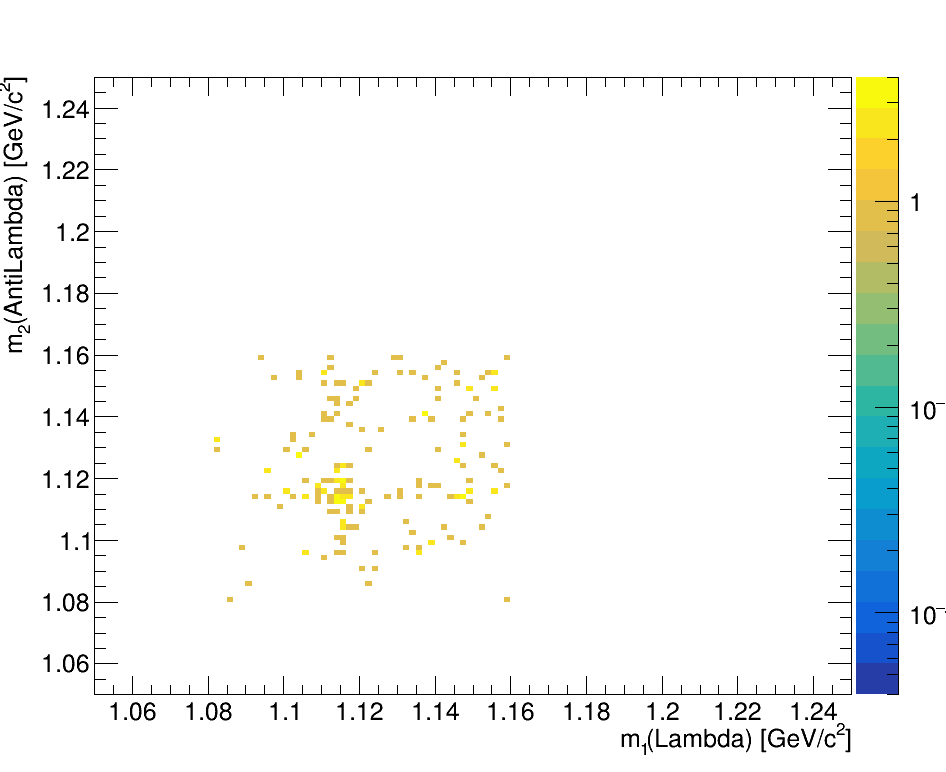

In [25]:
# Edit these five strings and rerun this cell.

source = "USUS"
pair_type = "LambdaAntiLambda"
range_name = "short"
crossing_class = "sameCrossing"
hist_name = "h_mass1_vs_mass2"

path = pair_path(
    source,
    pair_type,
    range_name,
    crossing_class,
    hist_name,
)

h = get_hist(path)

c_one = root.TCanvas("c_one", path, 950, 800)

if h.InheritsFrom("TH2"):
    if USE_LOGZ:
        root.gPad.SetLogz()
    h.Draw("colz")
else:
    h.Draw("hist e")

c_one.Update()
plot_keepalive.extend([c_one, h])

print(path)

## Low-statistics local-sideband analysis

This is the deliberately simple cross-check for the current small sample. It does **not** use the 2D Gaussian fit or US-LS normalization. A fixed central double-mass box contains signal plus a small background; the immediately surrounding rectangular ring estimates that local background. The ring is scaled by its mass-plane area and subtracted from the central-box `cos(theta*)` distribution.


In [26]:
def _expanded_window(window, scale, axis):
    c = 0.5 * (window[0] + window[1])
    h = 0.5 * (window[1] - window[0]) * scale
    return max(axis.GetXmin(), c-h), min(axis.GetXmax(), c+h)


def _bin_range(axis, window):
    b1 = axis.FindBin(window[0] + 1e-9)
    b2 = axis.FindBin(window[1] - 1e-9)
    b1 = max(1, min(axis.GetNbins(), b1))
    b2 = max(1, min(axis.GetNbins(), b2))
    return b1, b2, (axis.GetBinLowEdge(b1), axis.GetBinUpEdge(b2))


def _project_rect_z(h3, w1, w2, name):
    x1, x2, aw1 = _bin_range(h3.GetXaxis(), w1)
    y1, y2, aw2 = _bin_range(h3.GetYaxis(), w2)
    h = h3.ProjectionZ(name, x1, x2, y1, y2, "e")
    h.SetDirectory(0)
    h.Sumw2()
    if COS_REBIN > 1:
        h.Rebin(COS_REBIN)
    plot_keepalive.append(h)
    return h, aw1, aw2


def simple_local_sideband_extract(pair_type, range_name, crossing_class="sameCrossing"):
    species1, species2 = pair_type_species[pair_type]
    inner1 = fixed_windows[species1]
    inner2 = fixed_windows[species2]

    h3 = get_hist(pair_path("USUS", pair_type, range_name, crossing_class,
                            "h3_mass1_mass2_cosThetaStar"), required=False)
    h2 = get_hist(pair_path("USUS", pair_type, range_name, crossing_class,
                            "h_mass1_vs_mass2"), required=False)
    if not h3 or not h2:
        return None

    outer1 = _expanded_window(inner1, simple_sideband_outer_scale, h3.GetXaxis())
    outer2 = _expanded_window(inner2, simple_sideband_outer_scale, h3.GetYaxis())

    h_peak, ai1, ai2 = _project_rect_z(
        h3, inner1, inner2, f"h_simple_peak_{pair_type}_{range_name}_{crossing_class}")
    h_outer, ao1, ao2 = _project_rect_z(
        h3, outer1, outer2, f"h_simple_outer_{pair_type}_{range_name}_{crossing_class}")

    h_ring = clone_detached(h_outer, f"h_simple_ring_{pair_type}_{range_name}_{crossing_class}")
    h_ring.Add(h_peak, -1.0)

    area_inner = (ai1[1]-ai1[0]) * (ai2[1]-ai2[0])
    area_outer = (ao1[1]-ao1[0]) * (ao2[1]-ao2[0])
    area_ring = area_outer - area_inner
    bg_scale = area_inner / area_ring if area_ring > 0 else 0.0

    h_bg = clone_detached(h_ring, f"h_simple_bg_{pair_type}_{range_name}_{crossing_class}")
    h_bg.Scale(bg_scale)

    h_signal = clone_detached(h_peak, f"h_simple_signal_{pair_type}_{range_name}_{crossing_class}")
    h_signal.Add(h_bg, -1.0)

    n_peak = h_peak.Integral()
    n_bg = h_bg.Integral()
    bg_fraction = n_bg / n_peak if n_peak > 0 else float("nan")

    fit_signal = None
    if h_signal.Integral() >= min_entries_for_angular_fit:
        fit_signal = fit_cos_distribution(
            h_signal, pair_type, f"f_simple_signal_{pair_type}_{range_name}_{crossing_class}")

    fit_raw = None
    if h_peak.Integral() >= min_entries_for_angular_fit:
        fit_raw = fit_cos_distribution(
            h_peak, pair_type, f"f_simple_raw_{pair_type}_{range_name}_{crossing_class}")

    return {
        "h_mass2d": h2, "inner1": ai1, "inner2": ai2,
        "outer1": ao1, "outer2": ao2,
        "h_peak": h_peak, "h_bg": h_bg, "h_signal": h_signal,
        "bg_scale": bg_scale, "bg_fraction": bg_fraction,
        "fit_signal": fit_signal, "fit_raw": fit_raw,
    }


def _draw_mass_boxes(result):
    outer = root.TBox(result["outer1"][0], result["outer2"][0],
                      result["outer1"][1], result["outer2"][1])
    outer.SetFillStyle(0)
    outer.SetLineWidth(3)
    outer.SetLineStyle(2)
    outer.SetLineColor(root.kBlue+1)
    outer.Draw("same")

    inner = root.TBox(result["inner1"][0], result["inner2"][0],
                      result["inner1"][1], result["inner2"][1])
    inner.SetFillStyle(0)
    inner.SetLineWidth(3)
    inner.SetLineColor(root.kRed+1)
    inner.Draw("same")

    plot_keepalive.extend([inner, outer])
    return inner, outer


def make_simple_sideband_pdf(
    filename=os.path.join(plot_dir, "simple_local_sideband_analysis.pdf"),
    crossings=("sameCrossing", "differentCrossing"),
):
    canvas = root.TCanvas("c_simple_sideband", "simple local sideband", 1500, 1100)
    pdf_open(canvas, filename)
    results = {}

    for pair_type in pair_types:
        for range_name in ["short", "long"]:
            for crossing_class in crossings:
                r = simple_local_sideband_extract(pair_type, range_name, crossing_class)
                if r is None:
                    continue
                results[(pair_type, range_name, crossing_class)] = r

                canvas.Clear()
                canvas.Divide(2, 2)

                canvas.cd(1)
                if USE_LOGZ:
                    root.gPad.SetLogz()
                r["h_mass2d"].Draw("colz")
                inner, outer = _draw_mass_boxes(r)
                draw_legend([(inner, "central peak box", "l"),
                             (outer, "local sideband outer edge", "l")],
                            0.50, 0.74, 0.88, 0.88)

                canvas.cd(2)
                set_line(r["h_peak"], root.kBlack, 20)
                set_line(r["h_bg"], root.kRed+1, 24)
                ymax=max(r["h_peak"].GetMaximum(), r["h_bg"].GetMaximum())
                r["h_peak"].SetMaximum(1.3*ymax if ymax>0 else 1.0)
                r["h_peak"].Draw("hist e")
                r["h_bg"].Draw("hist e same")
                draw_legend([(r["h_peak"], "central box", "lep"),
                             (r["h_bg"], "scaled local sideband", "lep")])
                if math.isfinite(r["bg_fraction"]):
                    draw_label(f"background fraction = {r['bg_fraction']:.3f}", 0.17, 0.62, 0.032)

                canvas.cd(3)
                set_line(r["h_signal"], root.kBlue+1, 20)
                r["h_signal"].Draw("hist e")
                if r["fit_signal"]:
                    r["fit_signal"]["fit"].Draw("same")
                    draw_label(f"sideband-subtracted slope = {r['fit_signal']['slope']:+.3f} #pm {r['fit_signal']['slope_err']:.3f}", 0.15, 0.80, 0.030)
                    if math.isfinite(r["fit_signal"]["polarization"]):
                        draw_label(f"P = {r['fit_signal']['polarization']:+.3f} #pm {r['fit_signal']['polarization_err']:.3f}", 0.15, 0.73, 0.030)

                canvas.cd(4)
                hraw=clone_detached(r["h_peak"], f"hraw_{pair_type}_{range_name}_{crossing_class}")
                set_line(hraw, root.kBlack, 20)
                hraw.Draw("hist e")
                if r["fit_raw"]:
                    r["fit_raw"]["fit"].Draw("same")
                    draw_label(f"raw central-box slope = {r['fit_raw']['slope']:+.3f} #pm {r['fit_raw']['slope_err']:.3f}", 0.15, 0.80, 0.030)
                draw_label("minimal-assumption raw peak box", 0.15, 0.72, 0.030)

                draw_label(f"{pair_type}, {range_name}, {crossing_class}", 0.13, 0.94, 0.032)
                canvas.Print(filename)

    pdf_close(canvas, filename)
    print("Wrote", filename)
    return results


simple_sideband_results = {}
if MAKE_SIMPLE_SIDEBAND_ANALYSIS:
    simple_sideband_results = make_simple_sideband_pdf()


Wrote output/lambda_spin_plots/simple_local_sideband_analysis.pdf


Info in <TCanvas::Print>: pdf file output/lambda_spin_plots/simple_local_sideband_analysis.pdf has been created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Info in <TCanvas::Print>: Current canvas added to pdf file output/lambda_spin_plots/simple_local_sideband_analysis.pdf
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure alrea

## Notes for final physics use

- `sameCrossing` already means **both daughters of candidate 1 have the same valid crossing, both daughters of candidate 2 have the same valid crossing, and the two resolved candidate crossings are equal**.
- `differentCrossing` requires the same internal candidate consistency but the two candidate crossings differ.
- `K0SK0S`, `K0SLambda`, `K0SAntiLambda`, `LambdaPhi`, `AntiLambdaPhi`, and `K0SPhi` are useful controls.  Only the Lambda/Lambda-bar pair types are converted to the physical `P_Lambda1Lambda2` using the weak decay parameters.
- If mixed events were not produced, the notebook simply skips the ME correction.  No rerun is required for the raw same-event and crossing studies.
- For a final result, inspect the 2D mass fits carefully and tune the background-normalization / fit ranges rather than accepting the automatic defaults blindly.